In [5]:
import os
import torch
import numpy as np
import logging
import torch.optim as optim
import torch.nn.functional as F
from DataSet import CustomStrmDataset
from ConvAE_256res import ConvAutoEncoder
import torchvision.transforms as transform
from tqdm import tqdm
from datetime import datetime
import tractogramReader as tr
from utils_new import *
import time
from sklearn.metrics import r2_score


In [6]:
RANDOM_SEED = 42
res = 256
data_shape = [3, res]
latent_dim = 64
n_kernels = 32
kernel_size = 4
learning_rate = 1e-3
batch_size = 128
num_workers = 1
momentum = 0.9


In [7]:
device = set_device()
#seed_all(seed=RANDOM_SEED)

GPU is enabled. 



In [16]:
#tractogram = tr.T('../../Synthetic_tck/256res/100M_N256.tck'.encode("utf-8"))
tractogram = tr.T('../../AnomalyMap_HCP_synTrain/AnomalyMapping/HCP_test_11sub_N256.tck'.encode("utf-8"))

In [17]:
model_path = 'train_1_L1/checkpoints/AE45.pth'

model = ConvAutoEncoder(x_dim=data_shape, latent_dim=latent_dim, n_kernels=n_kernels, kernel_size=kernel_size)
#model.to(device)
model.load_state_dict(torch.load(model_path))
model.to(device)
model.eval()

4096


ConvAutoEncoder(
  (enc_conv_1): Conv1d(3, 32, kernel_size=(4,), stride=(2,), padding=(1,))
  (enc_conv_2): Conv1d(32, 64, kernel_size=(4,), stride=(2,), padding=(1,))
  (enc_conv_3): Conv1d(64, 128, kernel_size=(4,), stride=(2,), padding=(1,))
  (enc_conv_4): Conv1d(128, 256, kernel_size=(4,), stride=(2,), padding=(1,))
  (enc_conv_5): Conv1d(256, 512, kernel_size=(4,), stride=(2,), padding=(1,))
  (enc_flatten): Flatten(start_dim=1, end_dim=-1)
  (enc_lin): Linear(in_features=4096, out_features=64, bias=True)
  (dec_lin): Linear(in_features=64, out_features=4096, bias=True)
  (dec_unflatten): Unflatten(dim=-1, unflattened_size=(512, 8))
  (dec_deconv_1): ConvTranspose1d(512, 256, kernel_size=(4,), stride=(2,), padding=(1,))
  (dec_deconv_2): ConvTranspose1d(256, 128, kernel_size=(4,), stride=(2,), padding=(1,))
  (dec_deconv_3): ConvTranspose1d(128, 64, kernel_size=(4,), stride=(2,), padding=(1,))
  (dec_deconv_4): ConvTranspose1d(64, 32, kernel_size=(4,), stride=(2,), padding=(1,))


In [18]:
noPairs = 10000
random.seed(427)
randpairs_inds = np.empty([noPairs,2], dtype=np.int64)
for i in range(noPairs):
    randpairs_inds[i] = random.sample(range(tractogram.cntStreamline()), 2)

### Sample from the training data without replacement

In [19]:
streamlines_0 =  np.empty([noPairs,3,res])
streamlines_1 =  np.empty([noPairs,3,res])
for n in range(noPairs):
    streamlines_0[n] = np.asarray(tractogram.read(randpairs_inds[n,0])).transpose()
    streamlines_1[n] = np.asarray(tractogram.read(randpairs_inds[n,1])).transpose()
    
streamlines_0 = torch.from_numpy(streamlines_0).type(torch.FloatTensor).to(device)
streamlines_1 = torch.from_numpy(streamlines_1).type(torch.FloatTensor).to(device)

LS_0 = encode_strms(model, streamlines_0, batch_size, device,  RANDOM_SEED)
LS_1 = encode_strms(model, streamlines_1, batch_size, device,  RANDOM_SEED)


Using Seed Number 42
Using Seed Number 42


### Distances in streamline space

In [20]:
# MDF distance in the original space

dist_MDF= torch.zeros((noPairs,))
for i in range(noPairs):
    dist_MDF[i] = MDF_strms_dist(streamlines_0[i,:,:], streamlines_1[i,:,:])
    

In [21]:
dist_ED = torch.zeros((noPairs,))

for i in range(noPairs):
    dist_ED[i] = torch.sqrt(((LS_0[i]-LS_1[i])**2).sum())
        

In [22]:
rs, ps = stats.spearmanr(dist_ED,dist_MDF)
r, p =stats.pearsonr(dist_ED,dist_MDF)
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(dist_ED.flatten().cpu().reshape(-1,1),dist_MDF.flatten().cpu())
r2=model.score(dist_ED.flatten().cpu().reshape(-1,1),dist_MDF.flatten().cpu())

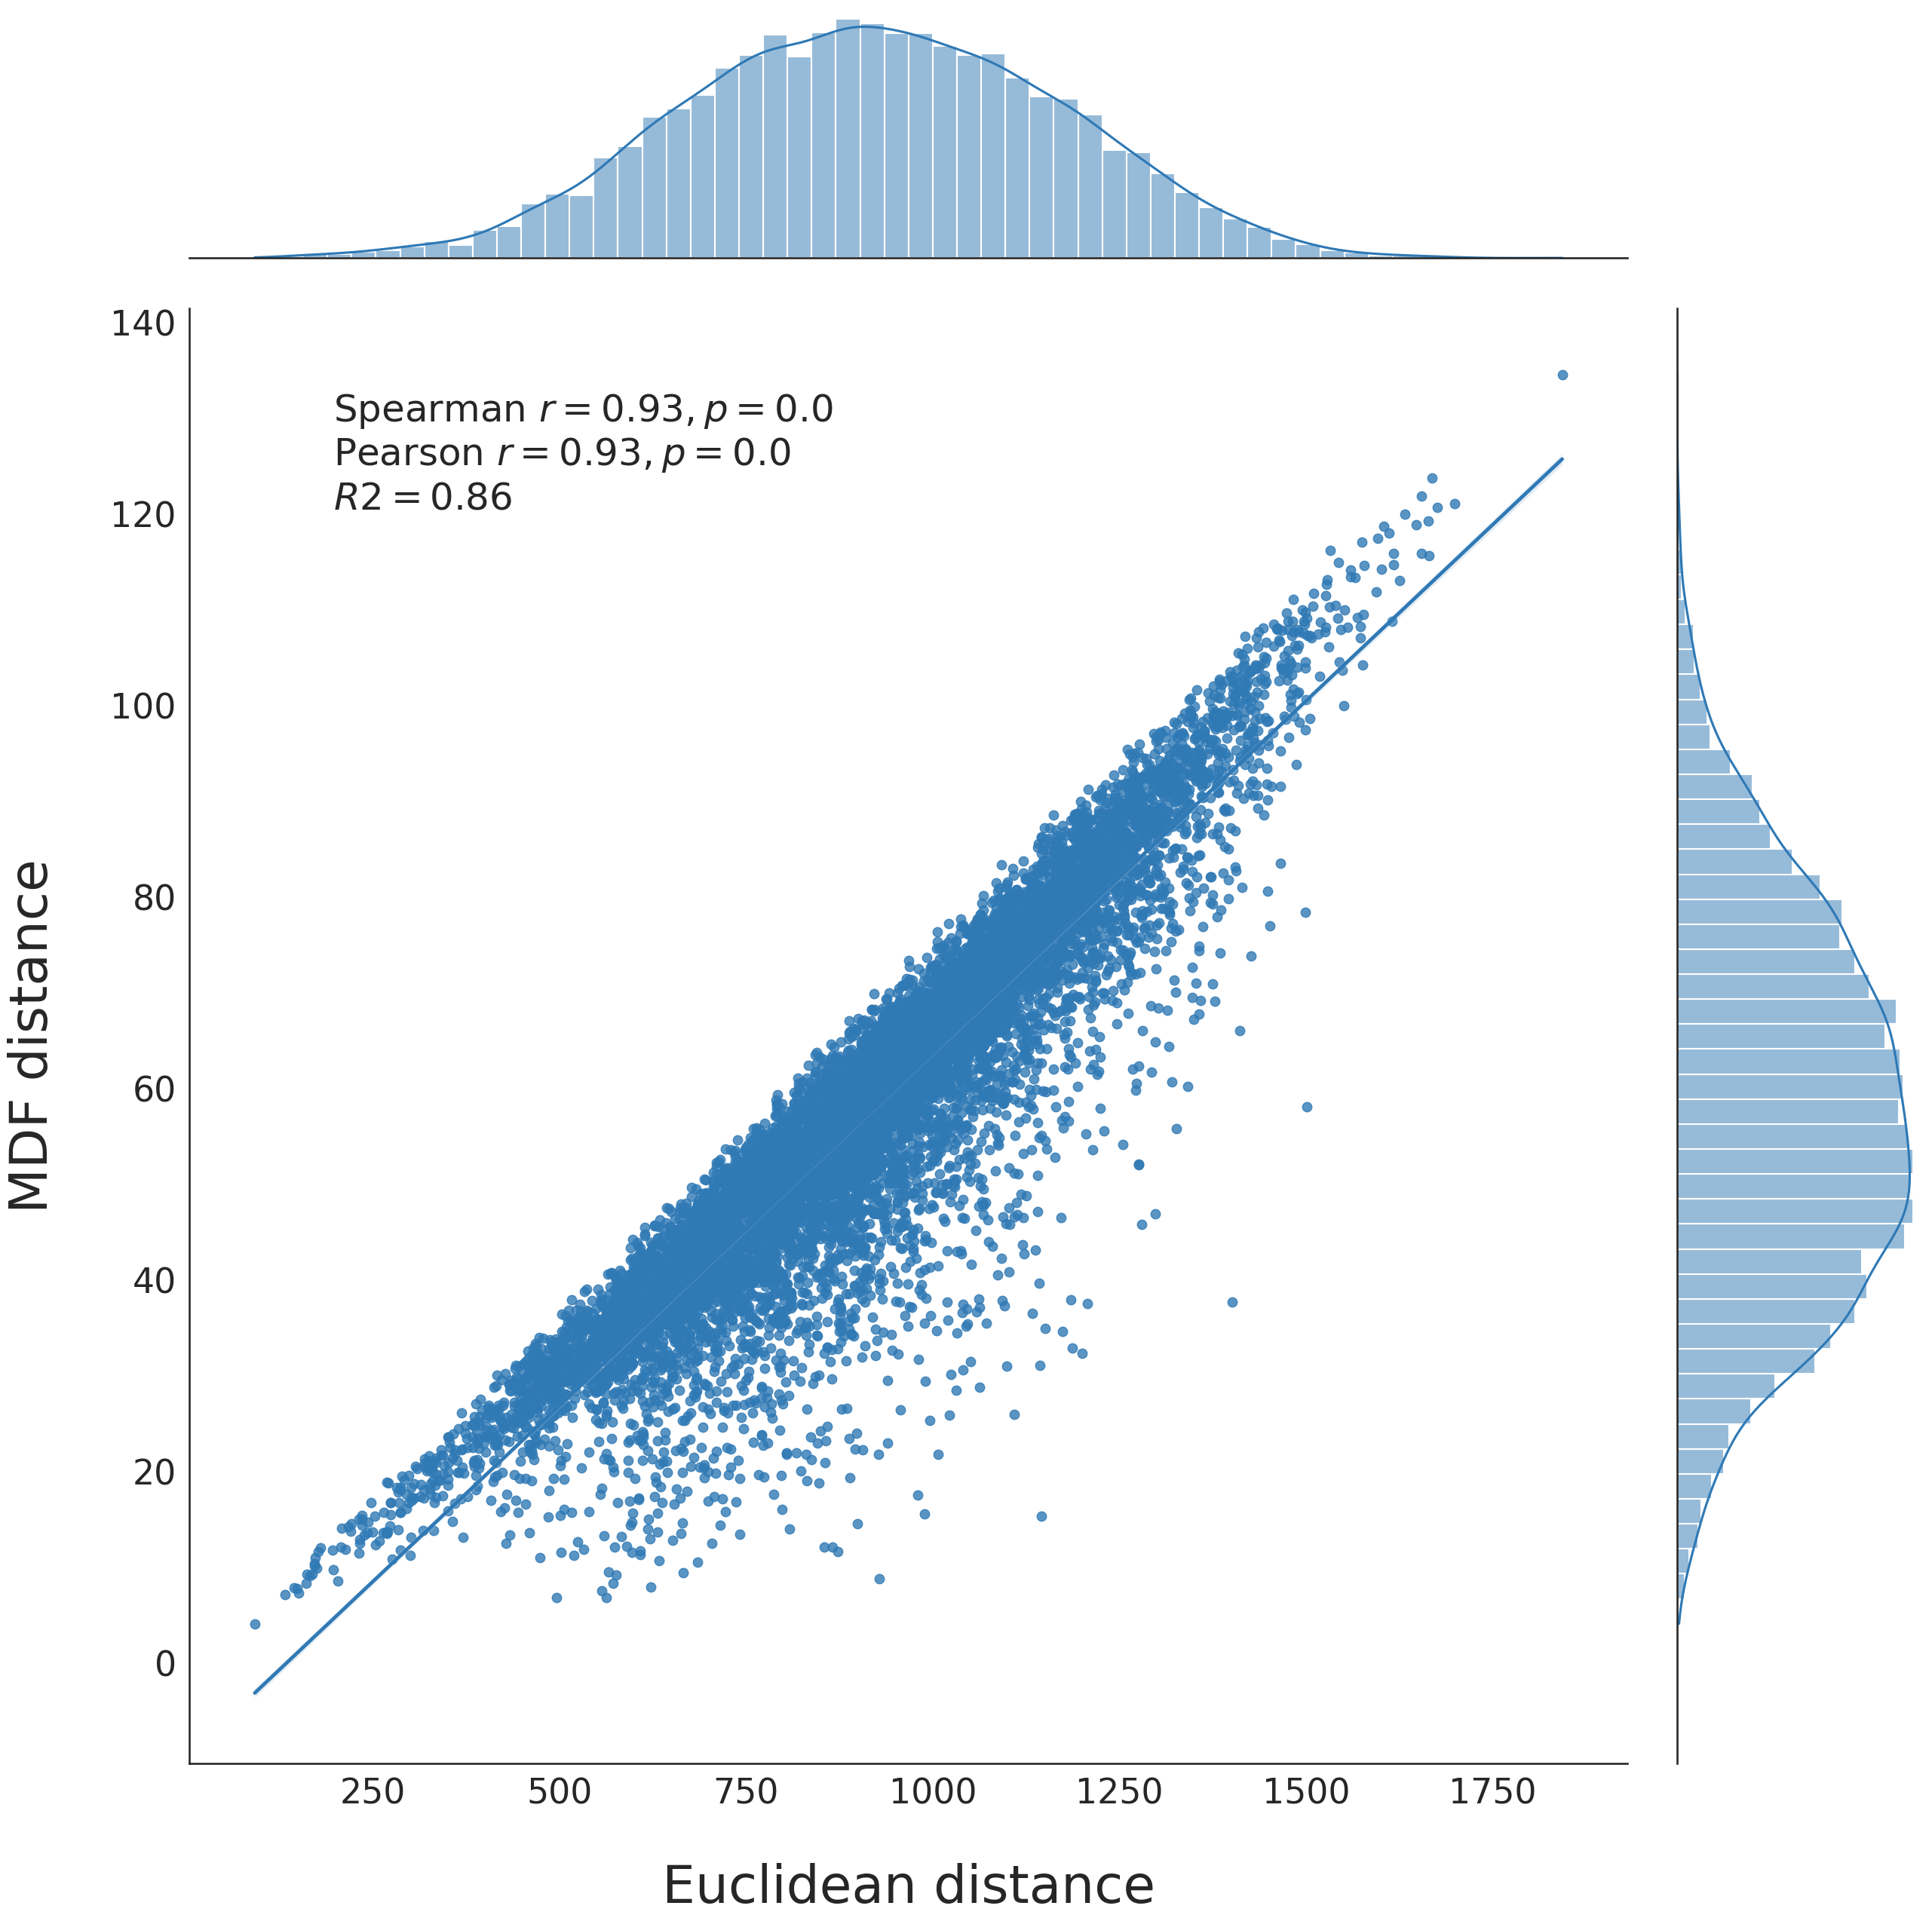

In [23]:
sns.set()
sns.set(style="white")
sns.set_context("talk", font_scale = 2) 
sns.set_palette(sns.color_palette("RdBu_r"))
g = sns.jointplot(x=dist_ED, y=dist_MDF, height=25, kind="reg")
r, p = stats.pearsonr(dist_ED,dist_MDF)
g.ax_joint.annotate(f'Spearman $r = {rs:.2f}, p = {ps:.1f}$ \nPearson $r = {r:.2f}, p = {p:.1f}$ \n$R2={r2:.2f}$',
                    xy=(0.1, 0.9), xycoords='axes fraction',
                    ha='left', va='center'
                   )
g.set_axis_labels(xlabel='Euclidean distance', ylabel='MDF distance', size=50, labelpad = 50)
g.savefig('dist_10kpairs_MDFvsED_11HCP_new.tiff', dpi=600)